In [18]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('/content/Advertising (1).csv', index_col=0)
df

Saving Advertising (1).csv to Advertising (1) (3).csv


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [20]:
# Step 3: Explore the data
print(df.head())
print(df.shape)
print(df.describe())
print(df.isnull().sum())  # check missing values

      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9
(200, 4)
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


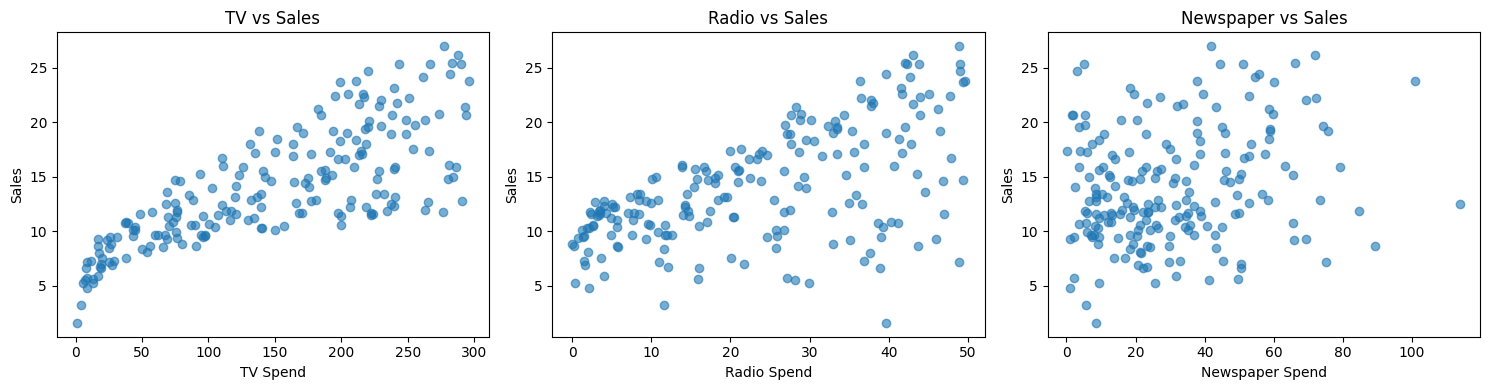

In [21]:
# Step 4: Visualize relationships between ad spend and sales
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
for i, col in enumerate(['TV', 'Radio', 'Newspaper']):
    plt.subplot(1, 3, i + 1)
    plt.scatter(df[col], df['Sales'], alpha=0.6)
    plt.xlabel(col + ' Spend')
    plt.ylabel('Sales')
    plt.title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

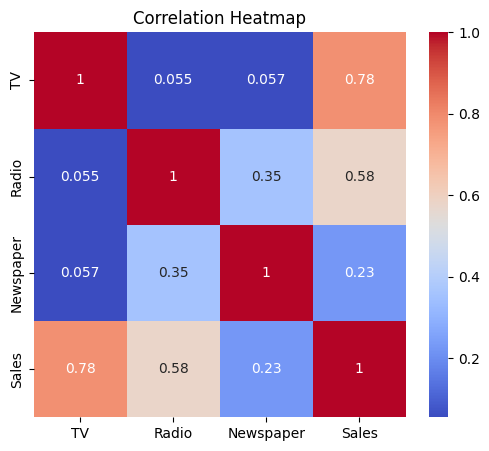

In [22]:
# Step 5: Correlation heatmap (shows which channel matters most)
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# Step 6: Prepare features (X) and target (y)
from sklearn.model_selection import train_test_split
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Step 7: Train a Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
# Step 8: Check model coefficients (how much each channel contributes)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coeff_df)
print(f"\nIntercept: {model.intercept_:.4f}")



Model Coefficients:
           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761

Intercept: 2.9791


In [25]:
# Step 9: Make predictions and evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

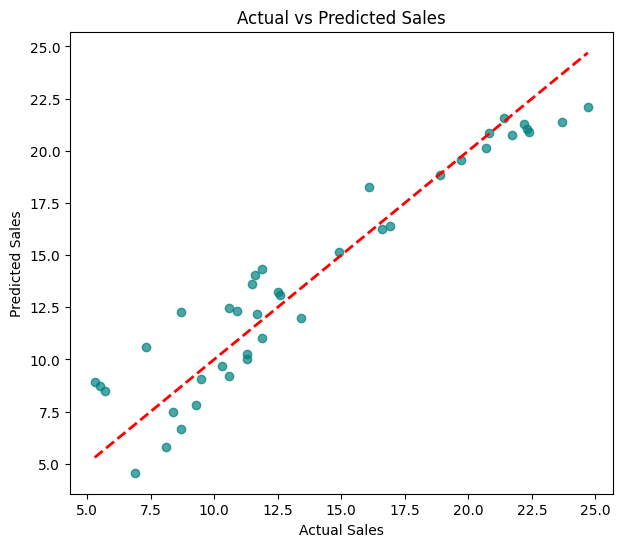

           TV      Radio  Newspaper      Sales
0  112.362036  32.101582  10.312387  13.391143
1  285.214292   4.206998  90.255291  15.715429
2  219.598183   8.081436  50.525237  14.408421
3  179.597545  44.927709  82.645747  18.313228
4   46.805592  30.321453  32.004960  10.132869


In [26]:
# Step 10: Plot Actual vs Predicted sales
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

np.random.seed(42)
n = 200
TV = np.random.uniform(0, 300, n)
Radio = np.random.uniform(0, 50, n)
Newspaper = np.random.uniform(0, 100, n)
Sales = 0.045*TV + 0.19*Radio + 0.003*Newspaper + np.random.normal(0, 1.5, n) + 3

df = pd.DataFrame({'TV': TV, 'Radio': Radio, 'Newspaper': Newspaper, 'Sales': Sales})
print(df.head())